<a href="https://colab.research.google.com/github/strongs-netizen/Oil_Spill_Detection/blob/main/Oil_Spill_Detection_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import datetime
print(f"Last updated: {datetime.datetime.now()}")

Last updated: 2026-05-07 11:49:31.708656


**Binary Classification**

Summary: In this task, we'll use PyTorch to build an Oil Spill Detection from Images using neural network model. We'll use this model to classify if there is oil spillage or not using some satellite image.

**Objectives:**

Convert images from grayscale to RGB



Resizes images



Create a transformation pipeline to standardize images for training



Build and train a simple neural network model in PyTorch



And deploy it with Streamlit.



In [2]:
pip install torchinfo

**Import Libraries**

In [3]:
import os
import shutil
import random
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import os
import sys
from collections import Counter

import seaborn as sns
import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchvision
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from sklearn.calibration import calibration_curve
from tqdm.version import __version__ as tqdm__version__
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split


torch.backends.cudnn.deterministic = True

In [4]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("CV2 version : ", cv2.__version__)
print("matplotlib version : ", matplotlib.__version__)
print("numpy version : ", np.__version__)
print("torch version : ", torch.__version__)
print("torchinfo version : ", torchinfo.__version__)
print("torchvision version : ", torchvision.__version__)
print("PIL version : ", PIL.__version__)
print("scikit-learn version: ", sklearn.__version__)
print("tqdm version: ", tqdm__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
CV2 version :  4.13.0
matplotlib version :  3.10.0
numpy version :  2.0.2
torch version :  2.10.0+cu128
torchinfo version :  1.8.0
torchvision version :  0.25.0+cu128
PIL version :  11.3.0
scikit-learn version:  1.6.1
tqdm version:  4.67.3


In [5]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


In [6]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [7]:
# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
# All key settings are gathered here
DATA_DIR    =  "/content/drive/MyDrive/capston/data" # root folder containing class subdirectories
CLASS_0_DIR = os.path.join(DATA_DIR, "S1SAR_UnBalanced_400by400_Class_0", "0")
CLASS_1_DIR = os.path.join(DATA_DIR, "S1SAR_UnBalanced_400by400_Class_1", "1")

IMG_SIZE    = 224               # resize all images to 224×224 pixels
BATCH_SIZE  = 32                # how many images to process at once
EPOCHS      = 20                # maximum number of training rounds
LR          = 1e-3              # learning rate — how fast the model adjusts
PATIENCE    = 5                 # stop early if validation F1 doesn't improve
MODEL_NAME  = "resnet50"        # architecture to use (change to your liking)
SAVE_PATH   = "best_oil_spill_model.pth"  # where to save the best model

# Label names for display
CLASS_NAMES = ["No Oil Spill", "Oil Spill"]

# Detect GPU; fall back to CPU if unavailable
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


**Load Image Paths and Labels**

In [9]:
# We scan each class folder to collect (image_path, label) pairs.
# Label 0 = no oil, Label 1 = oil spill.

print("[INFO] Scanning image folders...")
image_paths, labels = [], []
VALID_EXTENSIONS = (".png", ".jpg", ".jpeg", ".tif")

for img_name in os.listdir(CLASS_0_DIR):
    if img_name.lower().endswith(VALID_EXTENSIONS):
        image_paths.append(os.path.join(CLASS_0_DIR, img_name))
        labels.append(0)

for img_name in os.listdir(CLASS_1_DIR):
    if img_name.lower().endswith(VALID_EXTENSIONS):
        image_paths.append(os.path.join(CLASS_1_DIR, img_name))
        labels.append(1)

print(f"  Total images    : {len(image_paths)}")
print(f"  Class 0 (no oil): {labels.count(0)}")
print(f"  Class 1 (oil)   : {labels.count(1)}")

[INFO] Scanning image folders...
  Total images    : 5630
  Class 0 (no oil): 3725
  Class 1 (oil)   : 1905


**Train/ Validation / Test Split**

In [10]:
# We split data into 60% train, 20% val, 20% test.
# `stratify=labels` ensures both classes appear proportionally in each split.

X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, test_size=0.20, stratify=labels, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)  # 0.25 × 0.80 = 0.20 of total

print(f"\n[INFO] Data split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


[INFO] Data split → Train: 3378 | Val: 1126 | Test: 1126


**Handle Class Imbalance**

In [11]:
# SAR oil spill datasets are often imbalanced (far fewer oil images).
# We calculate class weights so the model pays more attention to the
# minority class during training.

class_counts_list = [y_train.count(0), y_train.count(1)]
class_weights = 1.0 / torch.tensor(class_counts_list, dtype=torch.float)
class_weights = class_weights / class_weights.sum()   # normalize to sum=1
print(f"[INFO] Class weights → {CLASS_NAMES[0]}: {class_weights[0]:.4f}  |  "
      f"{CLASS_NAMES[1]}: {class_weights[1]:.4f}")


[INFO] Class weights → No Oil Spill: 0.3384  |  Oil Spill: 0.6616


**Image Transformations**

In [12]:
#   - Training gets augmentation (flips, rotations) to help generalisation.
#   - Validation/test use only resize + normalize (no augmentation).
#
# Normalize values (mean/std) match ImageNet, which is standard for
# pretrained models like ResNet.

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),          # randomly mirror left↔right
    transforms.RandomVerticalFlip(),            # randomly mirror top↔bottom
    transforms.RandomRotation(10),              # rotate up to ±10 degrees
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),                      # convert PIL image → tensor
    transforms.Normalize(                       # standardize pixel values
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

**Custom Dataset Class**

In [13]:
# PyTorch needs a Dataset object that knows how to:
#   1. Report how many images exist  (__len__)
#   2. Return one (image, label) pair by index  (__getitem__)
#
# SAR images are often grayscale; we convert them to RGB because
# pretrained models expect 3-channel colour images.

class OilSpillDataset(Dataset):
    """Dataset for SAR oil spill images stored in flat directories."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths   # list of file paths
        self.labels      = labels        # list of integer labels (0 or 1)
        self.transform   = transform     # transformation pipeline

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Open image → convert to RGB (handles grayscale SAR images)
        image = Image.open(self.image_paths[idx]).convert("L").convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


# Build dataset objects for each split
train_dataset = OilSpillDataset(X_train, y_train, transform=train_transform)
val_dataset   = OilSpillDataset(X_val,   y_val,   transform=val_transform)
test_dataset  = OilSpillDataset(X_test,  y_test,  transform=val_transform)

**DataLoaders**

In [14]:
# DataLoaders wrap datasets and deliver images in batches during training.
# WeightedRandomSampler over-samples the minority class so the model
# sees a balanced mix of oil / no-oil images each epoch.

sample_weights = [class_weights[y].item() for y in y_train]
sampler = WeightedRandomSampler(
    sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"\n[INFO] DataLoaders ready → "
      f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


[INFO] DataLoaders ready → Train batches: 106 | Val batches: 36


**Build the Model**

In [15]:
# We use a pretrained ResNet50 from the `timm` library.
# "Pretrained" means the model has already learned general visual features
# (edges, textures, shapes) from millions of ImageNet images.
# We only swap the final classification head to predict our 2 classes.
#
# Why not a shallow MLP (like the Binary Classification notebook)?
# SAR satellite images have spatial patterns (oil sheen shapes, speckle)
# that convolutional networks capture far better than flat fully-connected
# networks. ResNet50 preserves spatial structure through its conv layers.

def build_model(model_name: str, num_classes: int = 2) -> nn.Module:
    """Create a pretrained model with a fresh classification head."""
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)

model = build_model(MODEL_NAME, num_classes=2)
print(f"\n[INFO] Model '{MODEL_NAME}' built and moved to {DEVICE}.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


[INFO] Model 'resnet50' built and moved to cuda.


**Loss Function**

In [16]:
# CrossEntropyLoss measures how wrong the model's predictions are.
# We pass `weight=class_weights` so the loss penalises mistakes on the
# minority class (oil spill) more heavily — the same idea as the
# weighted sampler, but applied at the loss level too.

loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

**Optimizer**

In [17]:
# Adam adjusts model weights after each batch using gradient descent.
# It's more sophisticated than basic SGD and converges faster.
# `lr` (learning rate) controls the step size — too high = unstable,
# too low = very slow.

optimizer = optim.Adam(model.parameters(), lr=LR)

**Training Helper Functions**

In [18]:
def train_one_epoch(model, optimizer, loss_fn, data_loader, device):
    """
    Run one full pass over the training data.

    For each batch:
      1. Feed images forward through the network → get logits
      2. Calculate the loss (how wrong we were)
      3. Backpropagate gradients (blame each weight for the error)
      4. Optimizer updates weights to reduce the loss
    """
    model.train()                    # enable dropout / batch-norm training mode
    total_loss = 0.0

    for images, targets in tqdm(data_loader, desc="  Training", leave=False):
        images  = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()        # clear gradients from the previous batch
        logits = model(images)       # forward pass: get raw predictions
        loss   = loss_fn(logits, targets)
        loss.backward()              # compute gradients via backpropagation
        optimizer.step()             # update weights

        total_loss += loss.item() * images.size(0)

    # Return the average loss over all images in this epoch
    return total_loss / len(data_loader.dataset)


def evaluate(model, data_loader, loss_fn, device):
    """
    Evaluate the model on a given dataset (validation or test).
    Returns: average loss, accuracy, and F1-score.
    """
    model.eval()                     # disable dropout / use running stats for BN
    total_loss  = 0.0
    all_preds   = []
    all_targets = []

    with torch.no_grad():            # no gradient computation needed for evaluation
        for images, targets in tqdm(data_loader, desc="  Evaluating", leave=False):
            images  = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            loss   = loss_fn(logits, targets)
            total_loss += loss.item() * images.size(0)

            preds = logits.argmax(dim=1)    # pick the class with highest score
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    f1       = f1_score(all_targets, all_preds, zero_division=0)
    return avg_loss, accuracy, f1

**Training Loop**

In [19]:
# This loop ties everything together.
# It also implements *early stopping*: if validation F1 doesn't improve
# for `PATIENCE` epochs, training stops to prevent overfitting.

print("\n" + "="*60)
print("  STARTING TRAINING")
print("="*60)

best_val_f1 = 0.0
epochs_without_improvement = 0

train_losses, val_losses, val_f1s = [], [], []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    # --- Train for one epoch ---
    train_loss = train_one_epoch(model, optimizer, loss_fn, train_loader, DEVICE)

    # --- Evaluate on validation set ---
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, loss_fn, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}  |  Val Accuracy: {val_acc:.4f}  |  Val F1: {val_f1:.4f}")

    # --- Save model if it improved ---
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✓ New best model saved (F1: {best_val_f1:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement ({epochs_without_improvement}/{PATIENCE})")

    # --- Early stopping ---
    if epochs_without_improvement >= PATIENCE:
        print(f"\n[INFO] Early stopping: no improvement for {PATIENCE} epochs.")
        break

print(f"\n[INFO] Training complete. Best Validation F1: {best_val_f1:.4f}")


  STARTING TRAINING

Epoch 1/20


  Training:   0%|          | 0/106 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

  Train Loss : 0.3196
  Val Loss   : 0.2785  |  Val Accuracy: 0.8908  |  Val F1: 0.8565
  ✓ New best model saved (F1: 0.8565)

Epoch 2/20


  Training:   0%|          | 0/106 [00:00<?, ?it/s]

...

  Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

  Train Loss : 0.0519
  Val Loss   : 0.1199  |  Val Accuracy: 0.9654  |  Val F1: 0.9490
  No improvement (4/5)

Epoch 14/20


  Training:   0%|          | 0/106 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

  Train Loss : 0.0463
  Val Loss   : 0.1011  |  Val Accuracy: 0.9636  |  Val F1: 0.9463
  No improvement (5/5)

[INFO] Early stopping: no improvement for 5 epochs.

[INFO] Training complete. Best Validation F1: 0.9646


**Load Best Model & Evaluate on Test Set**

In [20]:
# Always load the best saved weights before final evaluation.

print("\n[INFO] Loading best saved model for test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

test_loss, test_acc, test_f1 = evaluate(model, test_loader, loss_fn, DEVICE)
print(f"\n{'='*60}")
print("  FINAL TEST RESULTS")
print(f"{'='*60}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test F1 Score : {test_f1:.4f}")


[INFO] Loading best saved model for test evaluation...


  Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]


  FINAL TEST RESULTS
  Test Loss     : 0.1075
  Test Accuracy : 0.9680
  Test F1 Score : 0.9519


**Classification Report**

In [21]:
# Collect all predictions for the test set to build a full report.

model.eval()
all_preds_test, all_targets_test = [], []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(dim=1)
        all_preds_test.extend(preds.cpu().numpy())
        all_targets_test.extend(targets.numpy())

print("\n[INFO] Classification Report:")
print(classification_report(
    all_targets_test, all_preds_test, target_names=CLASS_NAMES
))


[INFO] Classification Report:
              precision    recall  f1-score   support

No Oil Spill       0.97      0.99      0.98       745
   Oil Spill       0.97      0.93      0.95       381

    accuracy                           0.97      1126
   macro avg       0.97      0.96      0.96      1126
weighted avg       0.97      0.97      0.97      1126



In [22]:
def predict(model, data_loader, device="cpu"):
    """
    Run the model on all images in data_loader and return probabilities.
    Returns a tensor of shape [num_images, num_classes].
    """
    all_probs = torch.tensor([]).to(device)

    model.eval()  # switch to evaluation mode (no dropout, etc.)

    with torch.no_grad():  # no gradient computation needed — saves memory
        for inputs, targets in tqdm(data_loader, desc="Predicting", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # Convert raw logits → probabilities using softmax
            probs = F.softmax(output, dim=1)
            all_probs = torch.cat((all_probs, probs), dim=0)

    return all_probs

In [23]:
probabilities_val = predict(model, val_loader, device)
predictions_val = torch.argmax(probabilities_val, dim=1)
print(predictions_val[:10])

Predicting:   0%|          | 0/36 [00:00<?, ?it/s]

tensor([0, 0, 0, 0, 0, 1, 0, 1, 1, 1], device='cuda:0')


**Confusion Matrix**

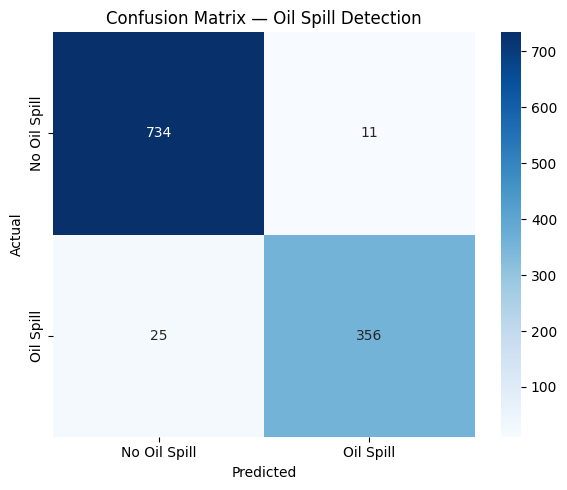

[INFO] Confusion matrix saved to confusion_matrix.png


In [24]:
# A confusion matrix shows us:
#   - True Positives  : predicted oil spill, actually oil spill
#   - True Negatives  : predicted no oil, actually no oil
#   - False Positives : predicted oil spill, actually no oil  (false alarm)
#   - False Negatives : predicted no oil, actually oil spill  (missed spill!)

cm = confusion_matrix(all_targets_test, all_preds_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Oil Spill Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("[INFO] Confusion matrix saved to confusion_matrix.png")

**Training Curves**

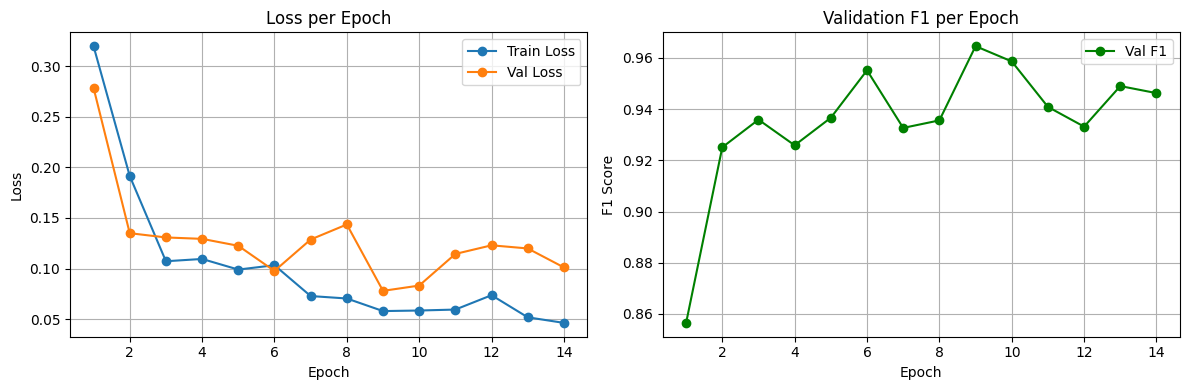

[INFO] Training curves saved to training_curves.png


In [25]:
# Visualising loss and F1 over epochs helps you understand:
#   - Is the model learning? (loss should decrease)
#   - Is it overfitting? (train loss keeps falling but val loss rises)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = list(range(1, len(train_losses) + 1))

axes[0].plot(epochs_ran, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_ran, val_losses,   label="Val Loss",   marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, val_f1s, label="Val F1", marker="o", color="green")
axes[1].set_title("Validation F1 per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("[INFO] Training curves saved to training_curves.png")

**Predict on a Single Image**

In [26]:
def predict_single_image(image_path: str, model: nn.Module, device: str) -> None:
    """Load one image, run it through the model, and print the result."""

    # Apply the same transforms used during validation
    image = Image.open(image_path).convert("L").convert("RGB")
    tensor = val_transform(image).unsqueeze(0).to(device)   # add batch dim

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1)[0]  # convert logits → probabilities

    predicted_class = probs.argmax().item()
    confidence      = probs[predicted_class].item()

    print(f"\n[PREDICTION] Image : {os.path.basename(image_path)}")
    print(f"             Label : {CLASS_NAMES[predicted_class]}")
    print(f"             Confidence : {confidence:.2%}")
    print(f"             Probabilities → "
          f"{CLASS_NAMES[0]}: {probs[0]:.4f}  |  {CLASS_NAMES[1]}: {probs[1]:.4f}")


# Example usage (uncomment and update path):
# predict_single_image("/path/to/your/image.png", model, DEVICE)

In [27]:
# Path to your specific folder in Drive
# Note: "My Drive" often has a space, so use exact spelling
folder_path = "/content/drive/MyDrive/capston/model"

# Define a FILENAME (e.g., myModel.pth) inside that folder
file_path = os.path.join(folder_path, "shallownet.pth")

# Save the weights
torch.save(model.state_dict(), file_path)
print(f"Success! Model saved to: {file_path}")


RuntimeError: Parent directory /content/drive/MyDrive/capston/model does not exist.

In [28]:
# Path to your specific folder in Drive
folder_path = "/content/drive/MyDrive/capston/model"

# Create the directory if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created directory: {folder_path}")

# Define a FILENAME inside that folder
file_path = os.path.join(folder_path, "shallownet.pth")

# Save the weights
# Note: 'model' variable was loaded from disk in cell 89O02735mUuA
torch.save(model.state_dict(), file_path)
print(f"Success! Model saved to: {file_path}")

Created directory: /content/drive/MyDrive/capston/model
Success! Model saved to: /content/drive/MyDrive/capston/model/shallownet.pth


In [30]:
import os
import torch

# Save to Google Drive so it persists after Colab session ends
save_path = "/content/drive/MyDrive/capston/model/oil_spill_model_weights.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)
print(f"✅ Model saved to: {save_path}")

✅ Model saved to: /content/drive/MyDrive/capston/model/oil_spill_model_weights.pth


In [31]:
model_test = timm.create_model("resnet50", pretrained=False, num_classes=2)
model_test.load_state_dict(torch.load(save_path, map_location="cpu"))
model_test.eval()
print("✅ Model loaded successfully — ready to deploy!")

✅ Model loaded successfully — ready to deploy!


In [32]:
MODEL_PATH = "/content/drive/MyDrive/capston/model/oil_spill_model_weights.pth"

**RELOAD THE MODEL**

In [34]:
import timm, torch
model = timm.create_model("resnet50", pretrained=False, num_classes=2)
model.load_state_dict(torch.load("/content/drive/MyDrive/capston/model/oil_spill_model_weights.pth", map_location="cpu"))
model.eval()

print("\n[INFO] Done! ✓")


[INFO] Done! ✓


In [39]:
import os
import torch

# Define the target directory and file path
save_directory = "/content/drive/MyDrive/capston/model"
save_path = os.path.join(save_directory, "oil_spill_model_weights.pth")

# Ensure the directory exists
os.makedirs(save_directory, exist_ok=True)

# Save the model state dictionary
torch.save(model.state_dict(), save_path)

print(f"✅ Model weights successfully saved to: {save_path}")

✅ Model weights successfully saved to: /content/drive/MyDrive/capston/model/oil_spill_model_weights.pth


### 🚀 Inference with Saved Weights
Now that the weights are saved to Google Drive, you can load them anytime to make predictions on new images.

In [43]:
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F

# 1. Re-instantiate the ResNet50 model used during training
inference_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
inference_model = inference_model.to(DEVICE)

# 2. Load the saved weights
weights_path = "/content/drive/MyDrive/capston/model/oil_spill_model_weights.pth"
inference_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))

# 3. Set to evaluation mode
inference_model.eval()

# 4. Run prediction on a test image
test_image_path = X_test[0]
predict_single_image(test_image_path, inference_model, DEVICE)


[PREDICTION] Image : 6_400_200_img_JmcZTGZ839wUMp4h_JAV_cls_1.jpg
             Label : Oil Spill
             Confidence : 50.36%
             Probabilities → No Oil Spill: 0.4964  |  Oil Spill: 0.5036


In [44]:
with open('/content/model.py', 'r') as f:
    print(f.read())

import torch.nn as nn

def build_model():
    model = nn.Sequential()

    # Conv Block 1
    model.append(nn.Conv2d(3, 16, kernel_size=3, padding=1))
    model.append(nn.ReLU())
    model.append(nn.MaxPool2d(2, 2))

    # Conv Block 2
    model.append(nn.Conv2d(16, 32, kernel_size=3, padding=1))
    model.append(nn.ReLU())
    model.append(nn.MaxPool2d(2, 2))

    # Conv Block 3
    model.append(nn.Conv2d(32, 64, kernel_size=3, padding=1))
    model.append(nn.ReLU())
    model.append(nn.MaxPool2d(2))

    # Classifier
    model.append(nn.Flatten())
    model.append(nn.Dropout())

    model.append(nn.Linear(50176, 500))
    model.append(nn.ReLU())
    model.append(nn.Dropout())

    model.append(nn.Linear(500, 8))

    return model
